<a href="https://colab.research.google.com/github/nagapandi1982/Colab-projects/blob/main/3DPlotting_Housepriceprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

In [5]:
data = pd.read_csv("https://raw.githubusercontent.com/nagapandi1982/Colab-projects/refs/heads/main/House%20prediction.txt", header=None)
X = data.iloc[:, 0:2]
y = data.iloc[:, 2]

In [6]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [7]:
# Extract as 1D arrays for plotting
size = X.iloc[:, 0].to_numpy()
bedrooms = X.iloc[:, 1].to_numpy()
price = y.to_numpy()

In [8]:
# Build a grid over the feature ranges
size_range = np.linspace(size.min(), size.max(), 20)
bedroom_range = np.linspace(bedrooms.min(), bedrooms.max(), 20)
size_grid, bedroom_grid = np.meshgrid(size_range, bedroom_range)

In [9]:
# Predict over the grid (make sure the order of columns matches training)
grid_points = np.c_[size_grid.ravel(), bedroom_grid.ravel()]
predicted_price = model.predict(grid_points)  # uses your trained model
price_grid = predicted_price.reshape(size_grid.shape)

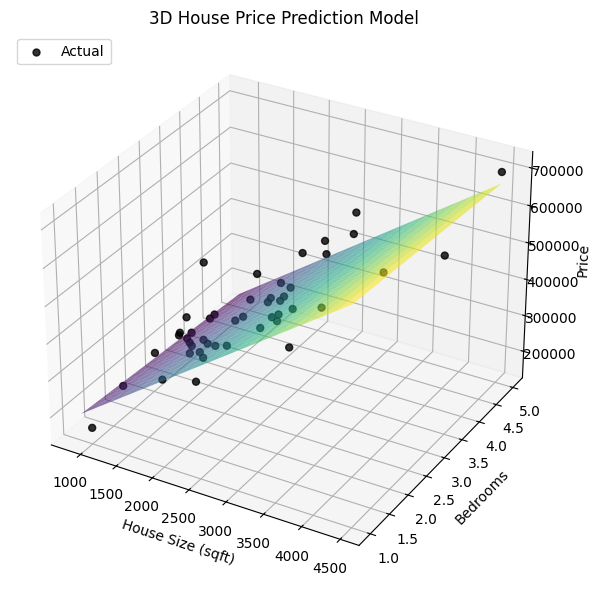

In [10]:
# Plot
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter actual points
ax.scatter(size, bedrooms, price, c='k', s=25, alpha=0.8, label='Actual')

# Predicted surface
ax.plot_surface(size_grid, bedroom_grid, price_grid,
                rstride=1, cstride=1, cmap='viridis', edgecolor='none',
                alpha=0.6)

ax.set_xlabel("House Size (sqft)")
ax.set_ylabel("Bedrooms")
ax.set_zlabel("Price")
ax.set_title("3D House Price Prediction Model")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()
